In [1]:
import requests
from bs4 import BeautifulSoup
import time
import pprint

# Base URL parts
base_url = "https://www.faa.gov"
main_url = f"{base_url}/newsroom/statements/accident_incidents#Top"

# Step 1: Get the main page and extract links to individual accident/incident articles
response = requests.get(main_url)
if response.status_code != 200:
    raise Exception(f"Error fetching {main_url}")

soup = BeautifulSoup(response.text, 'html.parser')

# The FAA page lists accident/incident articles. We assume that valid article links
# include '/newsroom/statements/' in their href attribute.
article_links = set()
for a in soup.find_all('a', href=True):
    href = a['href']
    if '/newsroom/statements/' in href:
        full_url = href if href.startswith('http') else base_url + href
        article_links.add(full_url)

print(f"Found {len(article_links)} article links.")

# Container for the scraped data
data_list = []

# Step 2: Visit each article link and parse the data
for article_url in article_links:
    print("Processing:", article_url)
    art_resp = requests.get(article_url)
    if art_resp.status_code != 200:
        print(f"Skipping {article_url}: HTTP {art_resp.status_code}")
        continue
    art_soup = BeautifulSoup(art_resp.text, 'html.parser')
    
    # Extract publication date (commonly in a <time> tag or a meta tag)
    date_str = ""
    time_tag = art_soup.find('time')
    if time_tag:
        date_str = time_tag.get_text(strip=True)
    else:
        meta_date = art_soup.find('meta', {'property': 'article:published_time'})
        if meta_date and meta_date.has_attr('content'):
            date_str = meta_date['content']

    # Extract the main content. Often, FAA pages use a WYSIWYG container (e.g., a div with class "wysiwyg").
    content_div = art_soup.find('div', class_='wysiwyg')
    if content_div:
        paragraphs = content_div.find_all('p')
        content_text = "\n".join(p.get_text(strip=True) for p in paragraphs)
    else:
        content_text = art_soup.get_text(separator="\n", strip=True)
    
    # Attempt to extract Category and Location.
    # Assume the first line of the content follows a pattern like "Commercial Aviation / Seattle, Washington"
    lines = content_text.splitlines()
    category = ""
    location = ""
    details = content_text  # default: all text
    if lines:
        first_line = lines[0]
        if "/" in first_line:
            parts = first_line.split("/")
            if len(parts) >= 2:
                category = parts[0].strip()
                location = parts[1].strip()
                # Exclude the first line from the details text
                details = "\n".join(lines[1:]).strip()
    
    data_dict = {
        "Date": date_str,
        "Category": category,
        "Location": location,
        "Details": details
    }
    data_list.append(data_dict)
    
    # Pause briefly to be respectful of the server's resources
    time.sleep(1)

# Print the resulting data list (or write it to a file as needed)
# pprint.pprint(data_list)

with open('faa-accident-incident-data.txt', 'w') as output:
    output.write(data_list[-1]['Details'])

Found 2 article links.
Processing: https://www.faa.gov/newsroom/statements/general-statements
Processing: https://www.faa.gov/newsroom/statements/accident_incidents


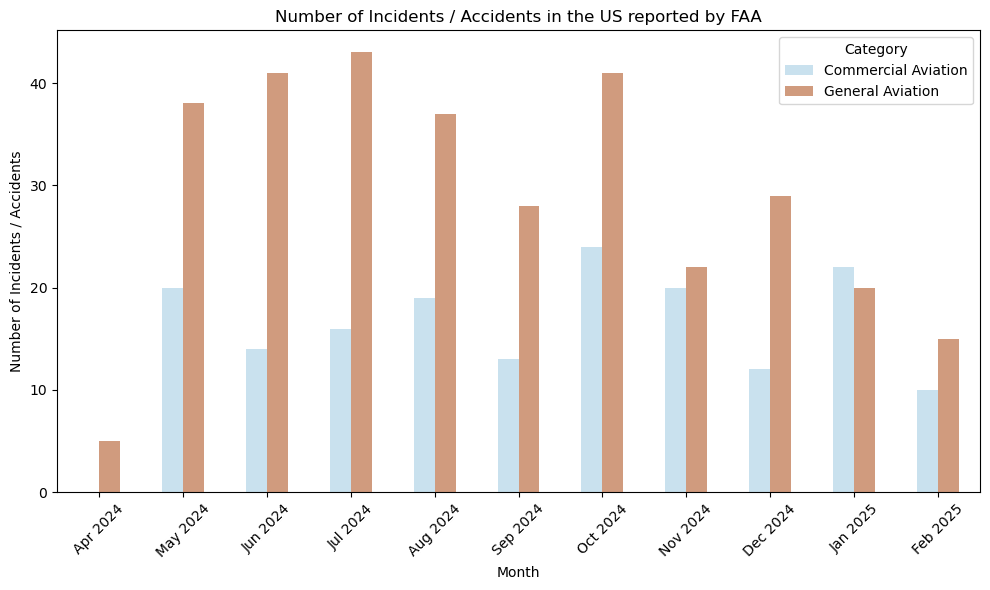

In [4]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import folium
from geopy.geocoders import Nominatim
from functools import lru_cache
import time

# ----------------------------
# 1. Read and Parse the Data
# ----------------------------

# Read the entire file as a string and then split into lines.
with open('faa-accident-incident-data.txt', 'r', encoding='utf-8') as f:
    content = f.read()

# If the file contains literal "\n" (backslash+n) instead of newlines, replace them.
if '\\n' in content:
    content = content.replace('\\n', '\n')

# Split content into individual lines and strip extra whitespace.
lines = [line.strip() for line in content.splitlines() if line.strip()]

# Define regex patterns:
# Date line (e.g., "February 12, 2025")
date_pattern = re.compile(r'^[A-Za-z]+\s+\d{1,2},\s+\d{4}$')
# Category/Location line (e.g., "Commercial Aviation / Chicago, Illinois")
cat_loc_pattern = re.compile(r'^(Commercial Aviation|General Aviation)\s*/\s*(.+)$')

records = []
current_date = None
i = 0

while i < len(lines):
    line = lines[i]
    # If the line matches a date pattern, update current_date
    if date_pattern.fullmatch(line):
        current_date = line
        i += 1
        continue
    
    # If the line matches category/location pattern, then assume next line is details.
    cat_loc_match = cat_loc_pattern.fullmatch(line)
    if cat_loc_match:
        category = cat_loc_match.group(1)
        location = cat_loc_match.group(2)
        # The next line is assumed to be the details.
        details = ""
        if i + 1 < len(lines):
            details = lines[i + 1]
        # Skip the details line and any separator line if present.
        i += 2
        if i < len(lines) and lines[i] == "Investigation and Other Information":
            i += 1
        # Append the record (using the current_date context)
        record = {
            "Date": current_date,
            "Category": category,
            "Location": location,
            "Details": details
        }
        records.append(record)
    else:
        # If the line is neither a date nor a category/location, skip it.
        i += 1

# ----------------------------
# 2. Create a DataFrame and Plot Histogram
# ----------------------------

# Create a pandas DataFrame from the records.
df = pd.DataFrame(records)

# Convert the Date column to datetime objects.
df['Date'] = pd.to_datetime(df['Date'], format='%B %d, %Y')

# Create a "Month" column formatted like "Feb 2025".
df['Month'] = df['Date'].dt.strftime('%b %Y')

# Group the data by Month and Category and count events.
grouped = df.groupby(['Month', 'Category']).size().unstack(fill_value=0)

# To ensure the months are sorted chronologically, convert the index back to datetime then sort.
grouped.index = pd.to_datetime(grouped.index, format='%b %Y')
grouped = grouped.sort_index()
grouped.index = grouped.index.strftime('%b %Y')

# Plot the grouped bar chart.
ax = grouped.plot(kind='bar', figsize=(10, 6), colormap='Paired', alpha=0.6)
# plt.xlabel('Month')
plt.ylabel('Number of Incidents / Accidents')
plt.title('Number of Incidents / Accidents in the US reported by FAA')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('faa-accidents-hist.png', dpi=300)
plt.show()

In [3]:
# ----------------------------
# 3. Create a US Map with Markers
# ----------------------------

# Initialize the geolocator using Nominatim.
geolocator = Nominatim(user_agent="faa_accidents_map")

@lru_cache(maxsize=128)
def geocode_location(location):
    try:
        loc = geolocator.geocode(location)
        if loc:
            return loc.latitude, loc.longitude
    except Exception as e:
        print(f"Error geocoding {location}: {e}")
    return None, None

# Create a base map centered over the US.
us_map = folium.Map(location=[39.8283, -98.5795], zoom_start=4)

# Define marker colors for each category.
color_dict = {
    "Commercial Aviation": 'blue',
    "General Aviation": 'black'
}

# Add a marker for each event.
for idx, row in df.iterrows():
    lat, lon = geocode_location(row['Location'])
    if lat is not None and lon is not None:
        folium.CircleMarker(
            location=[lat, lon],
            radius=5,
            popup=f"{row['Date'].strftime('%b %d, %Y')} - {row['Category']}: {row['Location']}",
            color=color_dict.get(row['Category'], 'green'),
            fill=True,
            fill_color=color_dict.get(row['Category'], 'green')
        ).add_to(us_map)
    else:
        print(f"Could not geocode location: {row['Location']}")
    # Pause briefly to respect rate limits.
    time.sleep(1)

# Save the map to an HTML file.
map_filename = "faa_events_map.html"
us_map.save(map_filename)
print(f"US map with FAA events has been saved to '{map_filename}'.")


Could not geocode location: U.S. Airlines Service Impacts
US map with FAA events has been saved to 'faa_events_map.html'.
